# Comparison between algorithms

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import cv2
import time
import sys

sys.path.append(os.path.abspath(".."))   # Add root path to sys.path
os.chdir("..")  # Change working directory to root path

from tqdm import tqdm
from datetime import datetime

### Nowcasting result

  Metric Dataset  Time leads (min)   titan     ata  etitan   iscit  stitan  \
0    POD  KARX_3             23.85  0.3897  0.3235  0.4461  0.4571  0.4687   
1    POD  KARX_5             35.92  0.2950  0.1903  0.3331  0.3556  0.3719   
2    POD  KDVN_3             19.08  0.3746  0.3339  0.4825  0.4473  0.4650   
3    POD  KDVN_5             28.78  0.2644  0.2143  0.3543  0.3420  0.3496   
4    POD  KGRR_3             22.27  0.2506  0.1940  0.3285  0.2646  0.3444   

     ours  
0  0.5152  
1  0.3975  
2  0.5070  
3  0.3930  
4  0.3605  


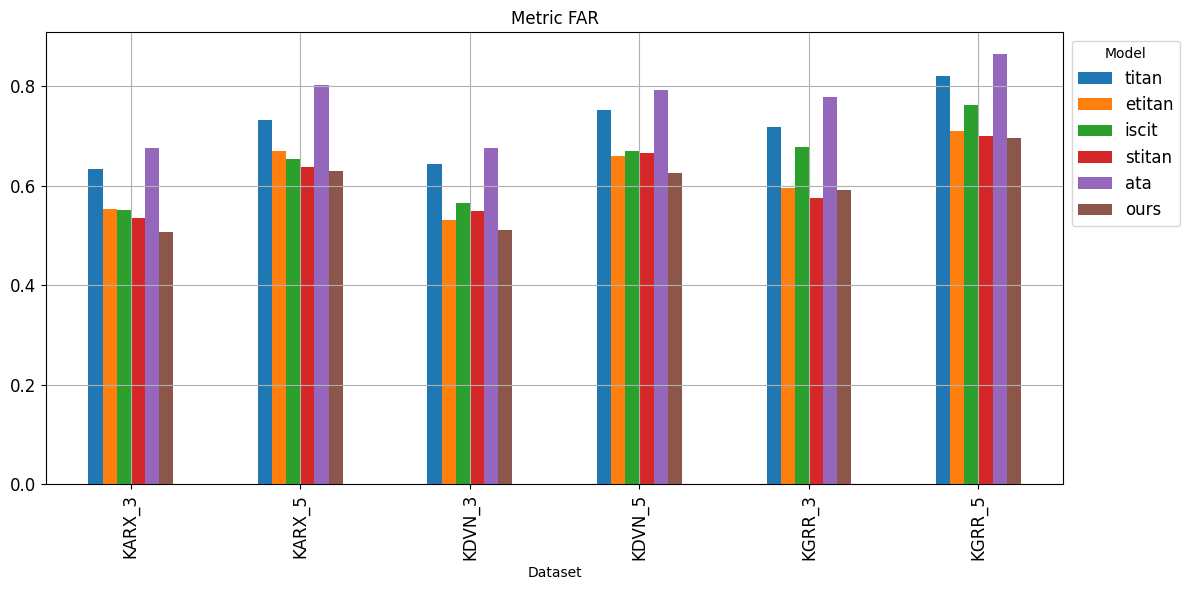

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Load the data
df = pd.read_csv("output/tracking/nowcasting_result_parsing.csv")
MODEL_NAME = ['titan', 'etitan', 'iscit', 'stitan', 'ata', 'ours']

print(df.head())

METRIC = 'FAR'
dataframe = df[df['Metric'] == METRIC].set_index('Dataset')
dataframe = dataframe.loc[:, MODEL_NAME]

dataframe.plot(kind='bar', figsize=(12, 6), title=f'Metric {METRIC}', grid=True, fontsize=12)
plt.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig(f'output/tracking/nowcasting_{METRIC}_comparison.png')
plt.show()

### Tracking Results

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Load the data
tracking_df = pd.read_csv("output/tracking/tracking_evaluation_results.csv")

tracking_metrics = ["Object Consistency", "Mean Duration", "Linear RMSE", "Optimal Tracking"]
units = ["(%)", "(frames)", "(pixels)", "(score)"]
tracking_columns = tracking_df.columns[2:]

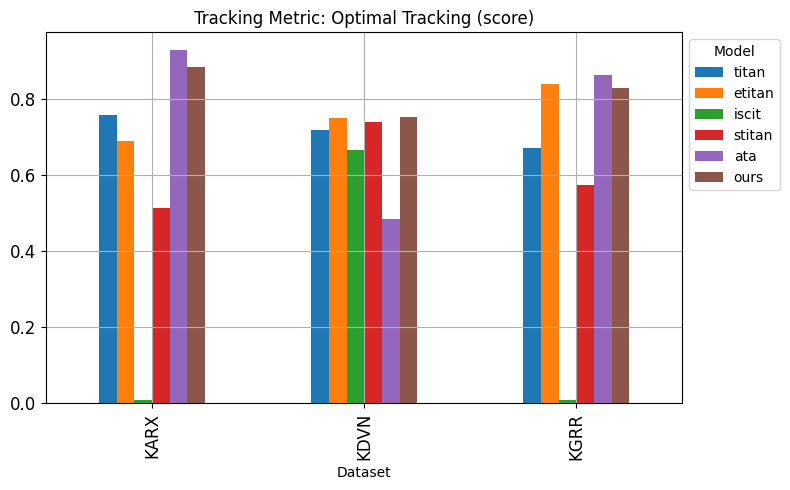

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

METRIC_IDX = 3
dataframe = tracking_df.loc[:, ["Dataset", "Model", tracking_columns[METRIC_IDX]]]
dataframe = dataframe.groupby(['Dataset', 'Model']).mean().unstack()
dataframe.columns = dataframe.columns.droplevel()

dataframe = dataframe.loc[:, MODEL_NAME]

dataframe.plot(kind='bar', figsize=(8, 5), title=f'Tracking Metric: {tracking_metrics[METRIC_IDX]} {units[METRIC_IDX]}', grid=True, fontsize=12)
plt.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left', fontsize=10)
plt.tight_layout()
# plt.ylim(reversed(plt.ylim()))  # Invert y-axis if lower is better
plt.savefig(f'output/tracking/tracking_{tracking_metrics[METRIC_IDX].replace(" ", "_").lower()}_comparison.png')

# Sensitivity Analysis

In [ ]:
DATASET = 'KARX'
dataframe = df[df['Dataset'] == DATASET].iloc[:, 1:]
dataframe.set_index('Model', inplace=True)
dataframe = dataframe.loc[['titan', 'etitan', 'iscit', 'stitan', 'ata', 'ours'], :]

x = np.arange(len(dataframe.index))

fig, ax1 = plt.subplots(figsize=(14, 8))
plt.subplots_adjust(right=0.75) # Make room on the right for extra axes

# 3. Create Twin Axes
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax4 = ax1.twinx()
ax5 = ax1.twinx()

ax3.spines["right"].set_position(("axes", 1.1))
# Move ax4 to the right by 1.3x
ax4.spines["right"].set_position(("axes", 1.2))
# Move ax5 to the right by 1.45x
ax5.spines["right"].set_position(("axes", 1.3))

# Object Consistency
object_consistency = dataframe.iloc[:, 0]
p2 = ax2.scatter(x, object_consistency, marker='o', color='tab:blue', label='Object Consistency', s=40, zorder=10)
ax2.set_ylabel("Object Consistency", color='tab:blue', fontweight='bold')
ax2.set_ylim(0, 6)
ax2.invert_yaxis()

# Mean Duration
mean_duration = dataframe.iloc[:, 1]
p3 = ax3.scatter(x, mean_duration, marker='o', color='tab:red', label='Mean Duration', s=40, zorder=10)
ax3.set_ylabel("Mean Duration", color='tab:red', fontweight='bold')
ax3.set_ylim(0, 12)

# Linearity Error
linearity_error = dataframe.iloc[:, 2]
p4 = ax4.scatter(x, linearity_error, marker='x', color='mediumturquoise', label='Linearity Error', s=40, zorder=10)
ax4.set_ylabel("Linearity Error", color='mediumturquoise', fontweight='bold')
ax4.set_ylim(0, 300)
ax4.invert_yaxis()

# Post-event Score
postevent_score = dataframe.iloc[:, 3]
p5 = ax5.scatter(x, postevent_score, marker='o', color='goldenrod', label='Post-event Score', s=40, zorder=10)
ax5.set_ylabel("Post-event Score", color='goldenrod', fontweight='bold')
ax5.set_ylim(0, 1)

ax2.tick_params(axis='y', colors='tab:blue')
ax3.tick_params(axis='y', colors='tab:red')
ax4.tick_params(axis='y', colors='mediumturquoise')
ax5.tick_params(axis='y', colors='goldenrod')

ax1.set_xticks(x)
ax1.set_xticklabels(dataframe.index, rotation=90)
ax1.set_xlim(-0.5, len(x) - 0.5)
ax1.grid(axis='x', linestyle='-', alpha=0.3)

plt.title(f"Tracking Analysis {DATASET}", fontsize=14)

plt.show()